<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-02/trabalho-02/demoD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import NewType, List
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics

# Tipo para representar cada ponto: um registro com features float
Point = NewType("Point", tuple[float, ...])

def dist(p: Point, q: Point) -> float:
  soma = 0
  for i in range(len(p)):
      # Calcula a diferença para cada feature
      soma += (p[i] - q[i]) ** 2

  return math.sqrt(soma)


def normalizacao(x: np.ndarray) -> np.ndarray:
  # Pegar os valores mínimos e máximos de cada feature
  mins = np.min(x, axis=0)
  maxs = np.max(x, axis=0)

  denom = maxs - mins # max(xi) - min(xi)
  denom[denom == 0] = 1

  return mins, denom

def aplicaNormalizacao(x: np.ndarray, mins: np.ndarray, denom: np.ndarray) -> np.ndarray:
  return (x - mins) / denom

def getDadosRotulo(dados: np.ndarray, rotulos: np.ndarray, rotulo: int, indice: int) -> List[int]:
    ret = []
    for idx in range(0, len(dados)):
        if(rotulos[idx] == rotulo):
            ret.append(dados[idx][indice])
    return ret

def visualizaPontos(dados: np.ndarray, rotulos: np.ndarray, d1: int, d2: int):
    fig, ax = plt.subplots()

    ax.scatter(getDadosRotulo(dados, rotulos, 1, d1), getDadosRotulo(dados, rotulos, 1, d2), c='red' , marker='^')
    ax.scatter(getDadosRotulo(dados, rotulos, 2, d1), getDadosRotulo(dados, rotulos, 2, d2), c='blue' , marker='+')
    ax.scatter(getDadosRotulo(dados, rotulos, 3, d1), getDadosRotulo(dados, rotulos, 3, d2), c='green', marker='.')

    plt.show()

def meuKnn(dadosTrain: np.ndarray, rotuloTrain: List[List[int]], dadosTeste: np.ndarray, k: int) -> np.ndarray:
  # Cria matriz de distâncias com dimensão nº de linhas de teste X nº de linhas de treino
  distances = np.ndarray(shape=(dadosTeste.shape[0], dadosTrain.shape[0]))
  predictions = np.zeros(shape=(dadosTeste.shape[0]))

  for row in range(dadosTeste.shape[0]):
    for col in range(dadosTrain.shape[0]):
      distances[row, col] = dist(dadosTeste[row], dadosTrain[col])

    # Armazena (distancia, rotulo) para todos os vizinhos
    closest_neighbors = [
        (v, rotuloTrain[i][0])
        for i, v in enumerate(distances[row])
    ]

    # Ordena os vizinhos pelo valor da distância
    closest_neighbors.sort(key=lambda x: x[0])

    # Mantém apenas os K vizinhos mais próximos
    predictions[row] = statistics.mode(
        [rot for (_, rot) in closest_neighbors[:k]]
    )

  return predictions


def calculaAcuracia(predicted_labels, test_labels):
  is_correct = [1 for i in range(len(test_labels)) if test_labels[i] == predicted_labels[i]]
  correct_total = sum(is_correct)
  total = len(test_labels)

  accuracy = correct_total / total
  return accuracy

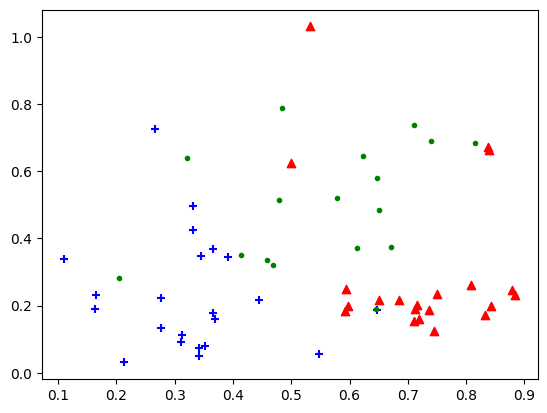

Acurácia: 0.9666666666666667


In [2]:
from scipy.io import loadmat

# Lê o dataset
data = loadmat('grupoDados2.mat')

# Faz escala contando com treino e teste
min_vals, denom = normalizacao(data['grupoTrain'])

# Ajusta os valores ao filtro normalizado
test_set = aplicaNormalizacao(data['grupoTest'], min_vals, denom)
train_set = aplicaNormalizacao(data['grupoTrain'], min_vals, denom)

train_labels = data['trainRots']
test_labels = data['testRots']

# Retorna previsão de rótulo para cada dado de teste
predicted_labels = meuKnn(train_set, train_labels, test_set, 1)

# Plota rótulos da previsão no gráfico
visualizaPontos(test_set, predicted_labels, 0, 1)

# Calcula acurácia da previsão
accuracy = calculaAcuracia(predicted_labels, test_labels)
print(f"Acurácia: {accuracy}")

### 1. Aplique seu kNN a este problema. Qual é a sua acurácia de classificação?
---
A acurácia é de 96%.

### 2. A acurácia pode ser igual a 98% com o kNN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou k de tal forma que a acurácia se torne 98% e explique o que você fez e por quê.
---
Com k = 1, a decisão depende apenas de um único vizinho, e isso pode levar a classificações incorretas quando um ponto de outra classe está muito próximo (como outliers).

Ao usar k = 3, a decisão passa a considerar mais vizinhos, reduzindo o impacto de pontos isolados e tornando a classificação mais robusta. Isso melhora a capacidade de generalização do modelo e leva a acurácia para 98%.

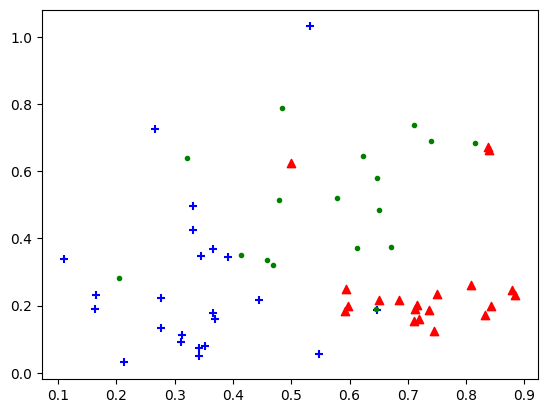

Acurácia: 0.9833333333333333


In [6]:
predicted_labels_3 = meuKnn(train_set, train_labels, test_set, 3)

visualizaPontos(test_set, predicted_labels_3, 0, 1)

accuracy = calculaAcuracia(predicted_labels_3, test_labels)
print(f"Acurácia: {accuracy}")